1. SINGLE INSIDER (Kyle, 1985)
trading intensity (beta) = 1.5000
price impact (lambda)    = 0.3333
expected profit          = 3.0000

2. N INSIDERS SHARING THE SAME SIGNAL (Nash equilibrium)
N=1 matches monopoly Kyle exactly: True True

   N       beta     lambda   profit/insider   total profit
   1     1.5000     0.3333           3.0000         3.0000
   2     1.0607     0.3143           1.4142         2.8284
   3     0.8660     0.2887           0.8660         2.5981
   5     0.6708     0.2485           0.4472         2.2361
  10     0.4743     0.1917           0.1725         1.7249
  25     0.3000     0.1282           0.0462         1.1538
  50     0.2121     0.0924           0.0166         0.8319
 100     0.1500     0.0660           0.0059         0.5941

-> Each insider trades LESS aggressively as N grows (beta falls),
   but total industry profit still shrinks toward 0 -- competition
   wins even though no single trader is trying to make it happen.

3. INDEPENDENT CHECK: closed fo

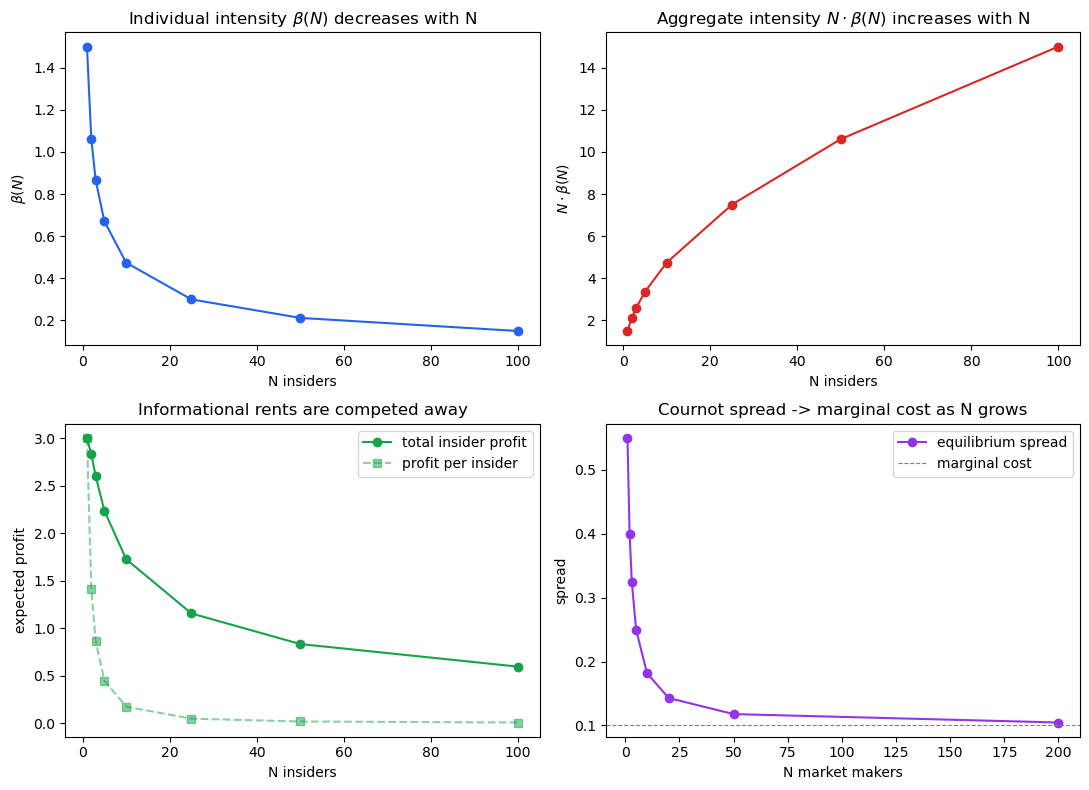

In [1]:
"""
Oligopoly & Nash Equilibria in Trading Strategies
====================================================

Two classic, genuinely game-theoretic results from market microstructure,
combined into one self-contained script (no installation, no internet,
just numpy):

1. N-INSIDER NASH EQUILIBRIUM (Kyle 1985 -> Holden & Subrahmanyam 1992)
   What happens when several traders all hold the SAME private information
   and compete against each other, instead of one monopolist insider?

2. COURNOT COMPETITION AMONG MARKET MAKERS
   Dealers competing on how much liquidity (depth) to supply, with the
   bid-ask spread emerging as the market-clearing price.

3. MONTE CARLO VALIDATION
   Simulates both markets thousands of times to check the closed-form
   theory actually holds up.
"""

from dataclasses import dataclass
import numpy as np


# =============================================================================
# 1. KYLE (1985): single monopolist insider
# =============================================================================

@dataclass
class KyleEquilibrium:
    sigma_v: float
    sigma_u: float
    beta: float
    lam: float
    expected_profit: float
    posterior_var: float


def solve_kyle(sigma_v: float, sigma_u: float) -> KyleEquilibrium:
    """
    Setup: one insider privately observes v ~ N(0, sigma_v^2). Noise traders
    submit u ~ N(0, sigma_u^2). A market maker sees only total order flow
    omega = x + u and prices at p = lambda * omega. The insider's optimal
    linear strategy x = beta * v and the market maker's lambda solve to:

        beta   = sigma_u / sigma_v
        lambda = sigma_v / (2 * sigma_u)
        E[profit] = (1/2) * sigma_v * sigma_u
    """
    if sigma_v <= 0 or sigma_u <= 0:
        raise ValueError("sigma_v and sigma_u must be strictly positive.")
    beta = sigma_u / sigma_v
    lam = sigma_v / (2.0 * sigma_u)
    expected_profit = 0.5 * sigma_v * sigma_u
    posterior_var = sigma_v ** 2 / 2.0
    return KyleEquilibrium(sigma_v, sigma_u, beta, lam, expected_profit, posterior_var)


# =============================================================================
# 2. N-INSIDER NASH EQUILIBRIUM (Holden & Subrahmanyam, 1992 extension)
# =============================================================================

@dataclass
class NashInsiderEquilibrium:
    n: int
    sigma_v: float
    sigma_u: float
    beta: float
    lam: float
    profit_per_insider: float
    total_insider_profit: float
    posterior_var: float


def solve_nash_insiders(n: int, sigma_v: float, sigma_u: float) -> NashInsiderEquilibrium:
    """
    N symmetric informed traders all observe the SAME signal v and compete
    simultaneously. Solving the symmetric linear Nash equilibrium gives:

        beta(N)   = sigma_u / (sigma_v * sqrt(N))
        lambda(N) = sigma_v * sqrt(N) / (sigma_u * (N + 1))
        profit_per_insider(N) = sigma_u * sigma_v / (sqrt(N) * (N + 1))

    N=1 collapses exactly to the monopoly Kyle (1985) result.

    Economic content: each INDIVIDUAL insider trades LESS aggressively as N
    grows (free-riding on shared information), but the AGGREGATE intensity
    N*beta(N) increases, the price becomes more informative, and the TOTAL
    rent N*profit_per_insider(N) still shrinks toward 0 as N -> infinity.
    """
    if n < 1:
        raise ValueError("n must be a positive integer (>= 1).")
    if sigma_v <= 0 or sigma_u <= 0:
        raise ValueError("sigma_v and sigma_u must be strictly positive.")

    sqrt_n = np.sqrt(n)
    beta = sigma_u / (sigma_v * sqrt_n)
    lam = sigma_v * sqrt_n / (sigma_u * (n + 1))
    profit_per_insider = sigma_u * sigma_v / (sqrt_n * (n + 1))
    total_profit = n * profit_per_insider

    var_v = sigma_v ** 2
    signal_to_total = (n * beta) ** 2 * var_v / ((n * beta) ** 2 * var_v + sigma_u ** 2)
    posterior_var = var_v * (1.0 - signal_to_total)

    return NashInsiderEquilibrium(
        n=n, sigma_v=sigma_v, sigma_u=sigma_u, beta=beta, lam=lam,
        profit_per_insider=profit_per_insider, total_insider_profit=total_profit,
        posterior_var=posterior_var,
    )


def solve_nash_insiders_numeric(n: int, sigma_v: float, sigma_u: float,
                                 tol: float = 1e-12, max_iter: int = 10_000) -> float:
    """
    Independent check: converge to beta(N) via damped best-response
    (fictitious-play) iteration, WITHOUT assuming the closed form.
    """
    beta = sigma_u / sigma_v
    for _ in range(max_iter):
        lam = n * beta * sigma_v ** 2 / ((n * beta) ** 2 * sigma_v ** 2 + sigma_u ** 2)
        beta_new = (1.0 - lam * (n - 1) * beta) / (2.0 * lam)
        if abs(beta_new - beta) < tol:
            return beta_new
        beta = beta_new
    return beta


def competition_curve(n_values, sigma_v: float, sigma_u: float):
    """Sweep N, return arrays of beta/lambda/profit/posterior_var for plotting."""
    betas, lams, per_profits, tot_profits, posts = [], [], [], [], []
    for n in n_values:
        eq = solve_nash_insiders(n, sigma_v, sigma_u)
        betas.append(eq.beta); lams.append(eq.lam)
        per_profits.append(eq.profit_per_insider); tot_profits.append(eq.total_insider_profit)
        posts.append(eq.posterior_var)
    return {
        "n": np.asarray(n_values), "beta": np.asarray(betas), "lambda": np.asarray(lams),
        "profit_per_insider": np.asarray(per_profits), "total_profit": np.asarray(tot_profits),
        "posterior_var": np.asarray(posts),
    }


# =============================================================================
# 3. COURNOT COMPETITION AMONG MARKET MAKERS
# =============================================================================

@dataclass
class CournotEquilibrium:
    a: float
    b: float
    costs: np.ndarray
    quantities: np.ndarray
    aggregate_depth: float
    spread: float
    profits: np.ndarray


def solve_cournot_symmetric(n: int, a: float, b: float, c: float) -> CournotEquilibrium:
    """
    N market makers choose depth q_i to maximize (s(Q)-c)*q_i against an
    inverse demand for liquidity s(Q) = a - b*Q. Standard N-firm Cournot:

        q_i* = (a - c) / (b * (N + 1))
        s*   = (a + N*c) / (N + 1)      -> converges to marginal cost c as N -> inf
    """
    if n < 1:
        raise ValueError("n must be >= 1")
    if b <= 0:
        raise ValueError("b (demand slope) must be positive")
    if a <= c:
        raise ValueError("Need a > c for positive equilibrium depth.")

    q = (a - c) / (b * (n + 1))
    Q = n * q
    s = a - b * Q
    profits = np.full(n, b * q ** 2)
    return CournotEquilibrium(a, b, np.full(n, c), np.full(n, q), Q, s, profits)


def solve_cournot_heterogeneous(a: float, b: float, costs) -> CournotEquilibrium:
    """Closed-form Cournot equilibrium with heterogeneous marginal costs c_i."""
    costs = np.asarray(costs, dtype=float)
    n = len(costs)
    if n < 1:
        raise ValueError("Need at least one market maker.")
    if b <= 0:
        raise ValueError("b (demand slope) must be positive")

    Q = (n * a - costs.sum()) / (b * (n + 1))
    q = (a - costs) / b - Q
    if np.any(q < 0):
        raise ValueError("Negative equilibrium depth for at least one firm -- "
                          "drop the high-cost firm(s) and re-solve over the rest.")
    s = a - b * Q
    profits = (s - costs) * q
    return CournotEquilibrium(a, b, costs, q, Q, s, profits)


def spread_vs_n_curve(n_values, a: float, b: float, c: float):
    """Sweep N (symmetric costs) and return equilibrium spreads/depths."""
    spreads, depths, profits = [], [], []
    for n in n_values:
        eq = solve_cournot_symmetric(n, a, b, c)
        spreads.append(eq.spread); depths.append(eq.aggregate_depth); profits.append(eq.profits[0])
    return {
        "n": np.asarray(n_values), "spread": np.asarray(spreads),
        "aggregate_depth": np.asarray(depths), "profit_per_firm": np.asarray(profits),
        "competitive_spread": c,
    }


# =============================================================================
# 4. MONTE CARLO VALIDATION
# =============================================================================

@dataclass
class NashSimulationResult:
    n: int
    n_trials: int
    theoretical_lambda: float
    empirical_lambda: float
    theoretical_profit_per_insider: float
    empirical_profit_per_insider: float


def simulate_nash_insiders(n: int, sigma_v: float, sigma_u: float,
                            n_trials: int = 20_000, seed: int = 0) -> NashSimulationResult:
    """Simulate the N-insider market n_trials times; recover empirical
    lambda (regress price on order flow) and profit, check vs theory."""
    rng = np.random.default_rng(seed)
    eq = solve_nash_insiders(n, sigma_v, sigma_u)

    v = rng.normal(0.0, sigma_v, size=n_trials)
    u = rng.normal(0.0, sigma_u, size=n_trials)
    x = eq.beta * v
    omega = n * x + u
    p = eq.lam * omega

    empirical_lambda = float(np.sum(omega * p) / np.sum(omega ** 2))
    empirical_profit = float(np.mean((v - p) * x))

    return NashSimulationResult(
        n=n, n_trials=n_trials, theoretical_lambda=eq.lam, empirical_lambda=empirical_lambda,
        theoretical_profit_per_insider=eq.profit_per_insider,
        empirical_profit_per_insider=empirical_profit,
    )


@dataclass
class CournotEntryResult:
    n_values: np.ndarray
    spreads: np.ndarray
    competitive_spread: float


def simulate_cournot_entry(n_values, a: float, b: float, c: float) -> CournotEntryResult:
    """Walk through market makers entering one at a time, N=1,2,3,...,
    tracking convergence of the equilibrium spread toward marginal cost."""
    spreads = [solve_cournot_symmetric(n, a, b, c).spread for n in n_values]
    return CournotEntryResult(np.asarray(n_values), np.asarray(spreads), c)


# =============================================================================
# 5. RUN IT
# =============================================================================

def main():
    sigma_v, sigma_u = 2.0, 3.0

    print("=" * 70)
    print("1. SINGLE INSIDER (Kyle, 1985)")
    print("=" * 70)
    kyle = solve_kyle(sigma_v, sigma_u)
    print(f"trading intensity (beta) = {kyle.beta:.4f}")
    print(f"price impact (lambda)    = {kyle.lam:.4f}")
    print(f"expected profit          = {kyle.expected_profit:.4f}")

    print()
    print("=" * 70)
    print("2. N INSIDERS SHARING THE SAME SIGNAL (Nash equilibrium)")
    print("=" * 70)
    n1 = solve_nash_insiders(1, sigma_v, sigma_u)
    print("N=1 matches monopoly Kyle exactly:",
          np.isclose(n1.beta, kyle.beta), np.isclose(n1.lam, kyle.lam))
    print()
    print(f"{'N':>4} {'beta':>10} {'lambda':>10} {'profit/insider':>16} {'total profit':>14}")
    for n in [1, 2, 3, 5, 10, 25, 50, 100]:
        eq = solve_nash_insiders(n, sigma_v, sigma_u)
        print(f"{n:>4} {eq.beta:>10.4f} {eq.lam:>10.4f} {eq.profit_per_insider:>16.4f} {eq.total_insider_profit:>14.4f}")
    print()
    print("-> Each insider trades LESS aggressively as N grows (beta falls),")
    print("   but total industry profit still shrinks toward 0 -- competition")
    print("   wins even though no single trader is trying to make it happen.")

    print()
    print("=" * 70)
    print("3. INDEPENDENT CHECK: closed form vs. best-response iteration")
    print("=" * 70)
    for n in [1, 2, 5, 10, 25]:
        closed = solve_nash_insiders(n, sigma_v, sigma_u).beta
        numeric = solve_nash_insiders_numeric(n, sigma_v, sigma_u)
        print(f"N={n:3d}   closed-form beta={closed:.6f}   best-response beta={numeric:.6f}   match={np.isclose(closed, numeric)}")

    print()
    print("=" * 70)
    print("4. SANITY CHECK: simulate the N=5 market 100,000 times")
    print("=" * 70)
    sim = simulate_nash_insiders(5, sigma_v, sigma_u, n_trials=100_000, seed=1)
    print(f"lambda  -- theory: {sim.theoretical_lambda:.5f}   simulated: {sim.empirical_lambda:.5f}")
    print(f"profit  -- theory: {sim.theoretical_profit_per_insider:.5f}   simulated: {sim.empirical_profit_per_insider:.5f}")
    print("(close match = the equilibrium formula is internally consistent)")

    print()
    print("=" * 70)
    print("5. MARKET MAKERS COMPETING ON SPREAD (Cournot)")
    print("=" * 70)
    a, b, c = 1.0, 0.01, 0.10
    print(f"{'N market makers':>16} {'equilibrium spread':>20} {'marginal cost':>15}")
    for n in [1, 2, 3, 5, 10, 20, 50, 200]:
        eq = solve_cournot_symmetric(n, a, b, c)
        print(f"{n:>16} {eq.spread:>20.5f} {c:>15.2f}")
    print()
    print("-> spread converges toward marginal cost as more market makers compete.")

    print()
    print("=" * 70)
    print("6. HETEROGENEOUS COSTS: who wins when one dealer is cheaper?")
    print("=" * 70)
    het = solve_cournot_heterogeneous(a=1.0, b=0.01, costs=[0.05, 0.15])
    print(f"Low-cost dealer  (c=0.05): quantity={het.quantities[0]:.2f}  profit={het.profits[0]:.4f}")
    print(f"High-cost dealer (c=0.15): quantity={het.quantities[1]:.2f}  profit={het.profits[1]:.4f}")
    print(f"Equilibrium spread: {het.spread:.4f}")

    # Optional charts
    try:
        import matplotlib.pyplot as plt

        ns = [1, 2, 3, 5, 10, 25, 50, 100]
        curve = competition_curve(ns, sigma_v, sigma_u)

        fig, axes = plt.subplots(2, 2, figsize=(11, 8))

        ax = axes[0, 0]
        ax.plot(curve["n"], curve["beta"], "o-", color="#2563eb")
        ax.set_title(r"Individual intensity $\beta(N)$ decreases with N")
        ax.set_xlabel("N insiders"); ax.set_ylabel(r"$\beta(N)$")

        ax = axes[0, 1]
        ax.plot(curve["n"], curve["n"] * curve["beta"], "o-", color="#dc2626")
        ax.set_title(r"Aggregate intensity $N \cdot \beta(N)$ increases with N")
        ax.set_xlabel("N insiders"); ax.set_ylabel(r"$N \cdot \beta(N)$")

        ax = axes[1, 0]
        ax.plot(curve["n"], curve["total_profit"], "o-", color="#16a34a", label="total insider profit")
        ax.plot(curve["n"], curve["profit_per_insider"], "s--", color="#16a34a", alpha=0.5, label="profit per insider")
        ax.set_title("Informational rents are competed away")
        ax.set_xlabel("N insiders"); ax.set_ylabel("expected profit"); ax.legend()

        ax = axes[1, 1]
        spread_curve = spread_vs_n_curve([1, 2, 3, 5, 10, 20, 50, 200], a, b, c)
        ax.plot(spread_curve["n"], spread_curve["spread"], "o-", color="#9333ea", label="equilibrium spread")
        ax.axhline(c, color="gray", ls="--", lw=0.8, label="marginal cost")
        ax.set_title("Cournot spread -> marginal cost as N grows")
        ax.set_xlabel("N market makers"); ax.set_ylabel("spread"); ax.legend()

        plt.tight_layout()
        plt.savefig("oligopoly_results.png", dpi=120)
        print("\nSaved chart to oligopoly_results.png")
    except ImportError:
        pass


if __name__ == "__main__":
    main()